# 🔧 02 - Preprocessing & Feature Engineering

**Objectif:** Nettoyer les données, créer des features et préparer le dataset pour l'entraînement.

In [1]:
import sys
from pathlib import Path
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import FraudPreprocessor
from src.feature_engineering import FraudFeatureEngineer
from src.utils import load_raw_data, save_dataframe

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

%matplotlib inline

## 1. Chargement et nettoyage

In [2]:
df = load_raw_data()
print(f"Shape initiale: {df.shape}")

preprocessor = FraudPreprocessor(scaler_type='robust')

# Nettoyage
df_clean = preprocessor.clean_data(df)
print(f"Après nettoyage: {df_clean.shape}")

# Outliers
df_clean = preprocessor.handle_outliers(df_clean, 'Amount', cap_percentile=99)
print(f"\nAmount stats après cap:")
print(df_clean['Amount'].describe())

2026-05-25 12:43:49.373 | INFO     | src.preprocessing:load_raw_data:29 - Dataset charge: (284807, 31)


Shape initiale: (284807, 31)


2026-05-25 12:43:50.310 | INFO     | src.preprocessing:clean_data:41 - Nettoyage: 284807 -> 283726 lignes (doublons supprimes=1081, lignes avec NaN supprimees=0)


Après nettoyage: (283726, 31)

Amount stats après cap:
count    283726.000000
mean         80.302958
std         159.413708
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max        1018.953750
Name: Amount, dtype: float64


## 2. Feature Engineering

In [3]:
engineer = FraudFeatureEngineer()
df_features = engineer.run(df_clean)

new_cols = [c for c in df_features.columns if c not in df_clean.columns]
print(f"Nouvelles features créées ({len(new_cols)}):")
for col in new_cols:
    print(f"  - {col}: min={df_features[col].min():.3f}, max={df_features[col].max():.3f}")

2026-05-25 12:43:50.635 | INFO     | src.feature_engineering:add_features:68 - Feature engineering: +9 features -> 40 colonnes


Nouvelles features créées (9):
  - transaction_hour: min=0.000, max=23.000
  - day_period: min=0.000, max=3.000
  - amount_log: min=0.000, max=6.928
  - amount_bin: min=0.000, max=3.000
  - v_mean: min=-7.084, max=0.802
  - v_std: min=0.390, max=40.276
  - risk_score: min=-57.183, max=92.690
  - amount_x_v14: min=0.000, max=10332.395
  - amount_x_v17: min=0.000, max=17838.427


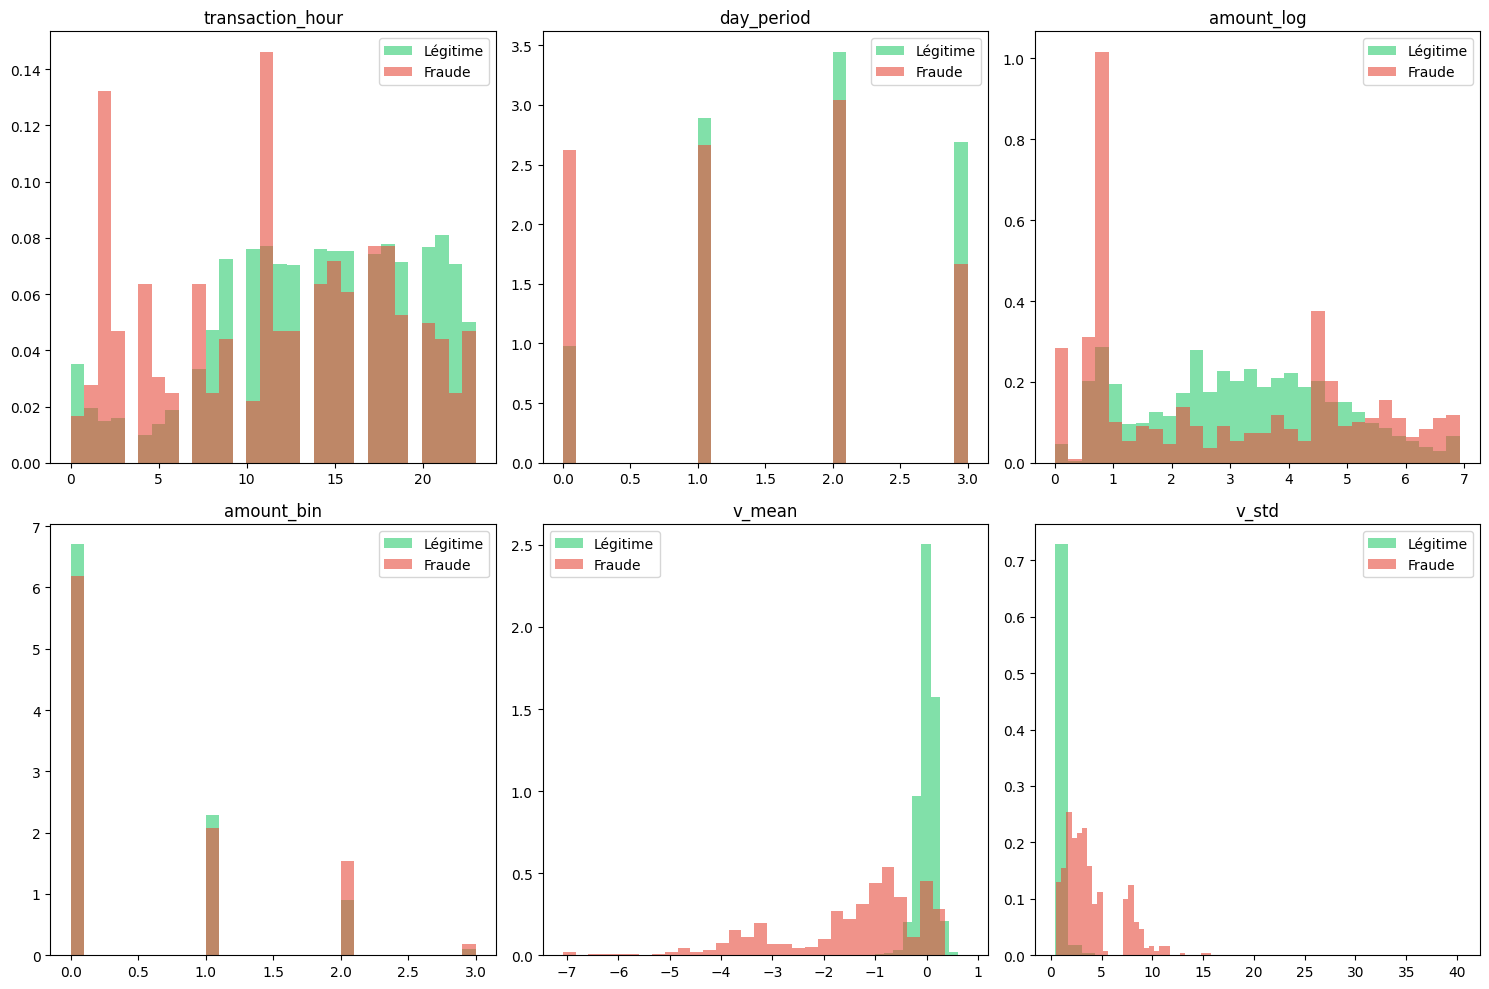

In [4]:
# Visualisation des nouvelles features vs fraude
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, new_cols[:6]):
    for cls, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        subset = df_features[df_features['Class'] == cls][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, density=True,
                label='Légitime' if cls == 0 else 'Fraude')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'new_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Scaling et Split

In [5]:
# Split avant tout scaling
X_train, X_val, X_test, y_train, y_val, y_test = preprocessor.split_train_val_test(
    df_features,
    val_size=0.15,
    test_size=0.15,
)

# Scaling fit uniquement sur le train
X_train = preprocessor.scale_features(X_train, fit=True)
X_val = preprocessor.scale_features(X_val)
X_test = preprocessor.scale_features(X_test)

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nDistribution train: {y_train.value_counts().to_dict()}")
print(f"Distribution val: {y_val.value_counts().to_dict()}")
print(f"Distribution test: {y_test.value_counts().to_dict()}")

2026-05-25 12:43:51.820 | INFO     | src.preprocessing:split_train_val_test:112 - Split train/val/test: train=198608, val=42559, test=42559


X_train: (198608, 39)
X_val: (42559, 39)
X_test: (42559, 39)

Distribution train: {0: 198277, 1: 331}
Distribution val: {0: 42488, 1: 71}
Distribution test: {0: 42488, 1: 71}


In [6]:
# Sauvegarde
save_dataframe(pd.concat([X_train, y_train], axis=1), 'train.csv')
save_dataframe(pd.concat([X_val, y_val], axis=1), 'val.csv')
save_dataframe(pd.concat([X_test, y_test], axis=1), 'test.csv')
print("✅ Données preprocessées sauvegardées: train.csv, val.csv, test.csv")

✅ Données preprocessées sauvegardées: train.csv, val.csv, test.csv


In [7]:
print(f"Valeurs manquantes: {df_clean.isnull().sum().sum()}")
print(f"Doublons: {df_clean.duplicated().sum()}")
print(f"\n✅ Dataset propre - pas de valeurs manquantes")
if df_clean.duplicated().sum() > 0:
    print(f"⚠️ {df_clean.duplicated().sum()} doublons à supprimer lors du preprocessing")

Valeurs manquantes: 0
Doublons: 0

✅ Dataset propre - pas de valeurs manquantes


## 4. Résumé

| Étape | Détails |
|-------|--------|
| Nettoyage | Suppression doublons + valeurs manquantes |
| Outliers | Cap Amount au 99e percentile |
| Features | +9 nouvelles features (temporelles, montant, agrégats, risque) |
| Scaling | RobustScaler sur Amount et Time, fit uniquement sur train |
| Split | 70/15/15 stratifié train / val / test |